# Análisis de Resultados ML - TMT → SSRT

Este notebook analiza los resultados del pipeline de regresión usando features de TMT para predecir SSRT.

**Fecha:** 19 de diciembre de 2025


In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline


## 1. Cargar Dataset


In [10]:
from src.model.datasetbuilder.dataset_builder import DatasetBuilder

builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset('tmt_ssrt')

print(f"Dataset: tmt_ssrt")
print(f"Target: {target_name}")
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"\nY stats:")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std: {y.std():.2f}")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")


Dataset: tmt_ssrt
Target: ssrt
Samples: 170
Features: 136

Y stats:
  Mean: 225.41
  Std: 51.88
  Min: 69.00
  Max: 354.00


Skipping line 88: expected 111 fields, saw 140



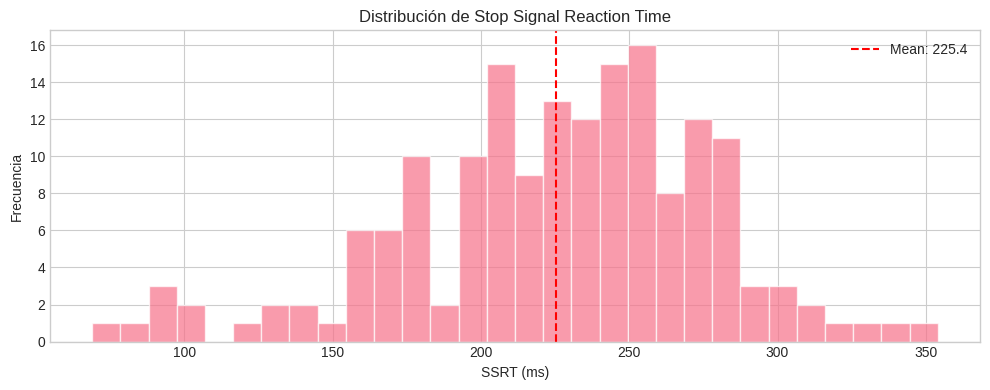

In [11]:
# Distribución del target
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y, bins=30, edgecolor='white', alpha=0.7)
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.1f}')
ax.set_xlabel('SSRT (ms)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Stop Signal Reaction Time')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Resultados de Regresión


In [ ]:
# Cargar resultados
from src.config import REGRESSION_RESULTS_DIR

# Buscar el último timestamp
results_path = Path(REGRESSION_RESULTS_DIR)
timestamps = sorted([d.name for d in results_path.iterdir() if d.is_dir()])
print(f"Timestamps disponibles: {timestamps}")

# Usar el último
TIMESTAMP = timestamps[-1] if timestamps else None
if TIMESTAMP is None:
    raise ValueError("No se encontraron resultados de regresión. Ejecuta el pipeline primero.")
print(f"\nUsando timestamp: {TIMESTAMP}")


Timestamps disponibles: ['test_new_api', 'test_tmt_ssrt']

Usando timestamp: test_tmt_ssrt


In [13]:
# Cargar summary
summary_path = results_path / TIMESTAMP / 'ssrt' / 'tmt_ssrt' / 'summary.csv'
summary_df = pd.read_csv(summary_path)

# Mostrar métricas principales
metrics_cols = ['model', 'r2', 'mse', 'mae']
print("Métricas de Regresión (LOOCV):")
print("=" * 60)
summary_df[metrics_cols].sort_values('r2', ascending=False)


Métricas de Regresión (LOOCV):


,model,r2,mse,mae
0,DummyRegressor,-0.011869,2723.959245,40.768535
6,SVR,-0.024988,2759.274549,40.781179
5,ElasticNet,-0.040078,2799.897366,41.272389
3,Lasso,-0.043828,2809.992335,41.460502
2,Ridge,-0.137480,3062.103443,43.383305
1,LinearRegression,-0.159651,3121.788884,43.775063
7,RandomForestRegressor,-0.228106,3306.069881,45.856765
4,XGBRegressor,-0.451864,3908.426851,48.636881


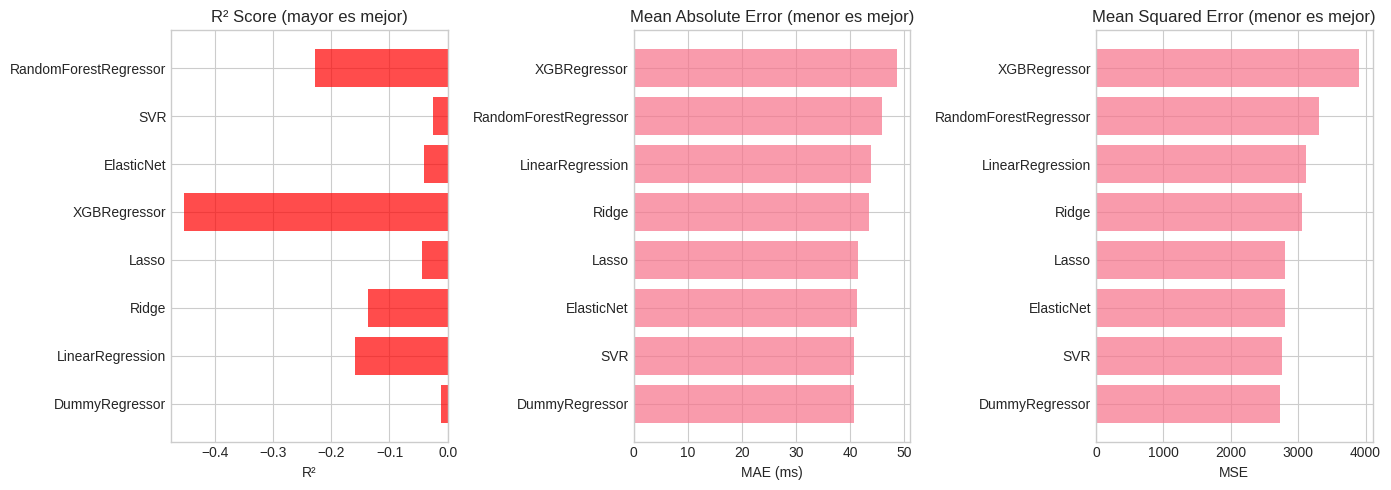

In [14]:
# Visualizar métricas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# R²
ax = axes[0]
colors = ['green' if x > 0 else 'red' for x in summary_df['r2']]
bars = ax.barh(summary_df['model'], summary_df['r2'], color=colors, alpha=0.7)
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('R²')
ax.set_title('R² Score (mayor es mejor)')

# MAE
ax = axes[1]
summary_sorted = summary_df.sort_values('mae')
ax.barh(summary_sorted['model'], summary_sorted['mae'], alpha=0.7)
ax.set_xlabel('MAE (ms)')
ax.set_title('Mean Absolute Error (menor es mejor)')

# MSE
ax = axes[2]
summary_sorted = summary_df.sort_values('mse')
ax.barh(summary_sorted['model'], summary_sorted['mse'], alpha=0.7)
ax.set_xlabel('MSE')
ax.set_title('Mean Squared Error (menor es mejor)')

plt.tight_layout()
plt.show()


## 3. Predicciones vs Valores Reales


In [15]:
# Cargar folds
folds_path = results_path / TIMESTAMP / 'ssrt' / 'tmt_ssrt' / 'folds.csv'
folds_df = pd.read_csv(folds_path)

print(f"Total de predicciones: {len(folds_df)}")
print(f"Modelos: {folds_df['model'].unique()}")


Total de predicciones: 1360
Modelos: ['DummyRegressor' 'LinearRegression' 'Ridge' 'Lasso' 'XGBRegressor'
 'ElasticNet' 'SVR' 'RandomForestRegressor']


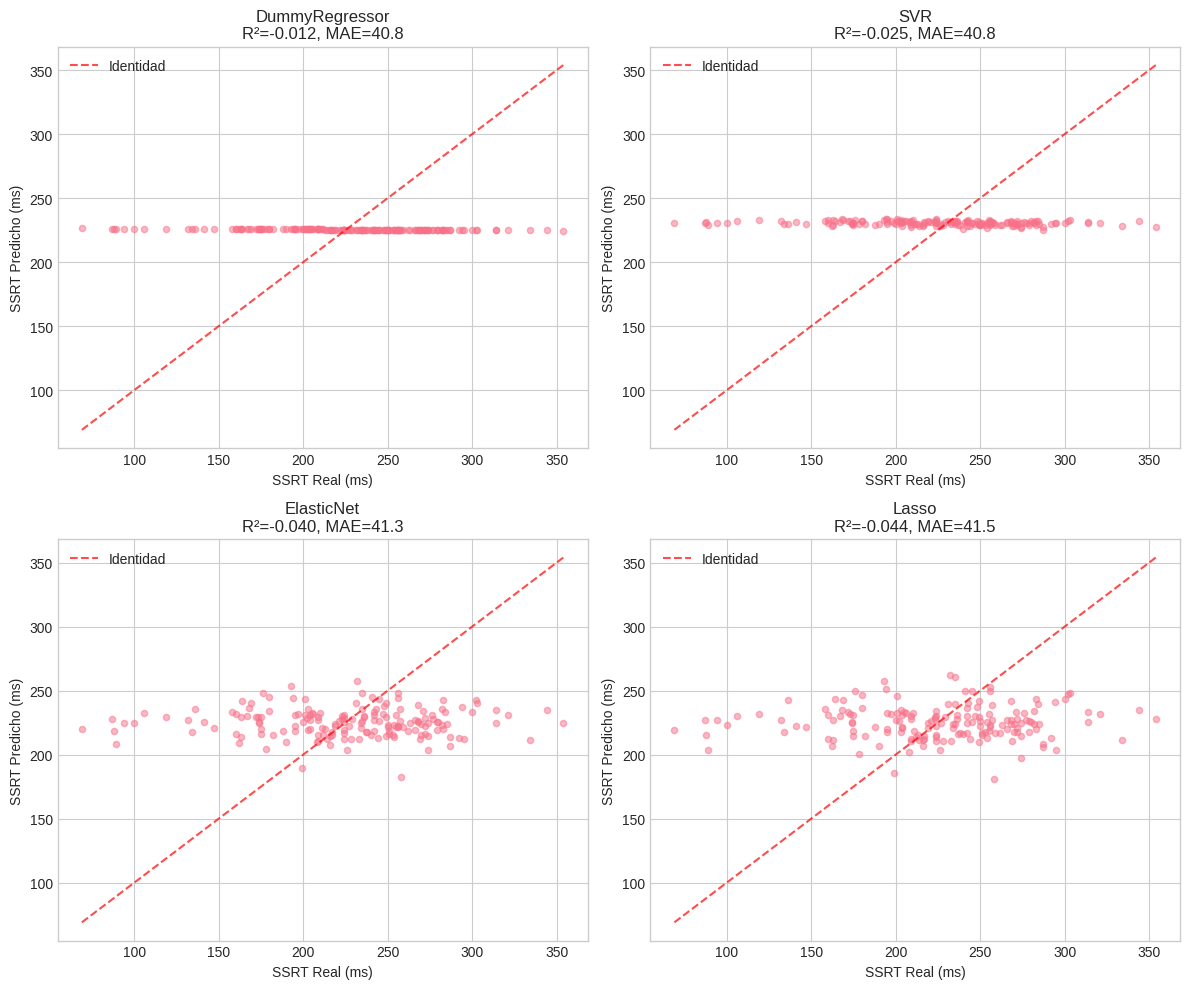

In [16]:
# Plot predicciones vs real para los mejores modelos
best_models = summary_df.nsmallest(4, 'mae')['model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model in zip(axes, best_models):
    model_data = folds_df[folds_df['model'] == model]
    
    ax.scatter(model_data['y_test'], model_data['y_pred'], alpha=0.5, s=20)
    
    # Línea de identidad
    lims = [min(model_data['y_test'].min(), model_data['y_pred'].min()),
            max(model_data['y_test'].max(), model_data['y_pred'].max())]
    ax.plot(lims, lims, 'r--', alpha=0.7, label='Identidad')
    
    # Métricas
    r2 = summary_df[summary_df['model'] == model]['r2'].values[0]
    mae = summary_df[summary_df['model'] == model]['mae'].values[0]
    
    ax.set_xlabel('SSRT Real (ms)')
    ax.set_ylabel('SSRT Predicho (ms)')
    ax.set_title(f'{model}\nR²={r2:.3f}, MAE={mae:.1f}')
    ax.legend()

plt.tight_layout()
plt.show()


## 4. Análisis SHAP

SHAP (SHapley Additive exPlanations) nos permite entender qué features son más importantes para las predicciones.


In [17]:
from src.model.shap.run_shap import run_shap
from src.model.shap.analyze_shap_results import analyze_shap_results

# Elegir modelo para SHAP
MODEL_TO_EXPLAIN = 'Ridge'

print(f"Ejecutando SHAP para {MODEL_TO_EXPLAIN}...")
print("(Esto puede tomar varios minutos)")


Ejecutando SHAP para Ridge...
(Esto puede tomar varios minutos)


/home/gianluca/Research/datapruebas_analysis/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
%%time
# Ejecutar SHAP
shap_explanations, target_name = run_shap(
    task='regression',
    dataset_name='tmt_ssrt',
    timestamp=TIMESTAMP,
    model_name_to_explain=MODEL_TO_EXPLAIN
)

print(f"\nExplicaciones generadas: {len(shap_explanations)}")


Skipping line 88: expected 111 fields, saw 140

Skipping line 88: expected 111 fields, saw 140



[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers.

In [19]:
# Analizar resultados SHAP
shap_df = analyze_shap_results(shap_explanations, task='regression', fillna_zero=False)

print("Top 15 Features por Importancia SHAP:")
print("=" * 50)
shap_df.head(15)


Top 15 Features por Importancia SHAP:


,mean_abs_shap,freq_selection
non_cut_std_negative_acceleration_PART_B,128.408248,0.005882
non_cut_wrong_targets_touches_PART_A,119.604856,0.005882
mean_negative_acceleration_PART_A,95.150000,0.005882
mean_negative_acceleration_PART_B,65.795592,0.011765
non_cut_mean_abs_acceleration_PART_B,35.582432,0.005882
inter_target_time_PART_A,28.474012,0.005882
non_cut_mean_negative_acceleration_PART_B,24.407459,0.041176
area_difference_from_ideal_PART_B,23.519105,0.017647
mean_speed_PART_B,17.701391,0.988235
hesitation_time_PART_A,16.178766,1.000000


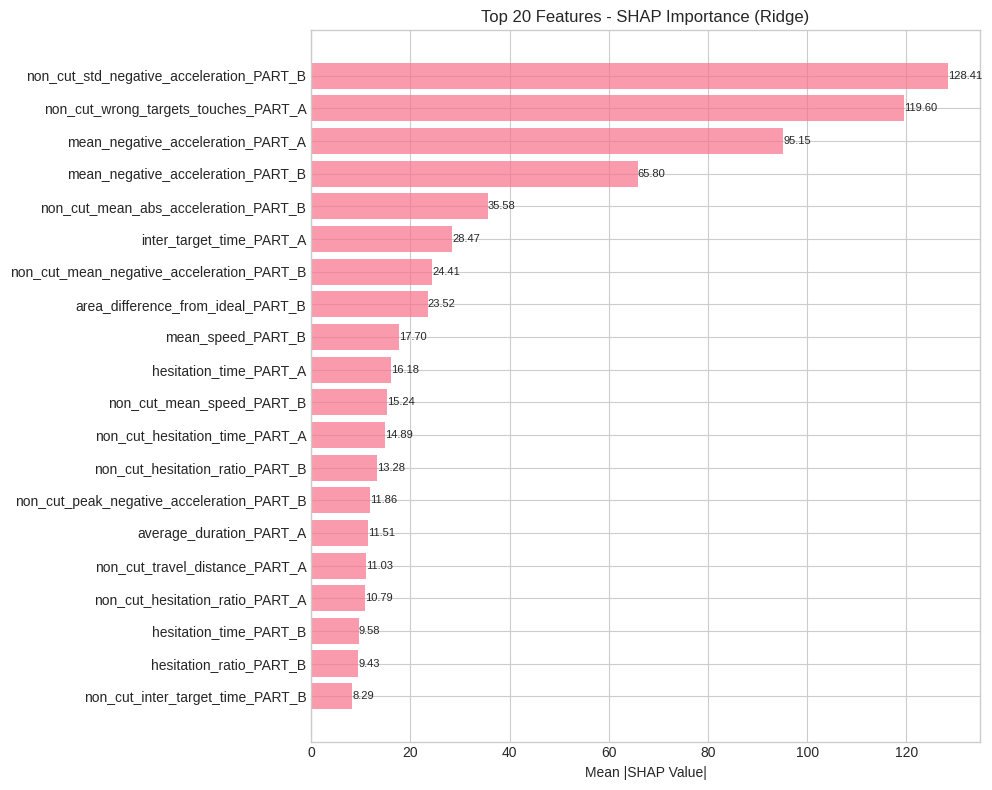

In [20]:
# Visualizar importancia SHAP
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
top_features = shap_df.head(top_n).sort_values('mean_abs_shap')

bars = ax.barh(top_features.index, top_features['mean_abs_shap'], alpha=0.7)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(f'Top {top_n} Features - SHAP Importance ({MODEL_TO_EXPLAIN})')

# Añadir valores
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()


## 5. Resumen


In [21]:
print("="*60)
print("RESUMEN DE RESULTADOS")
print("="*60)
print(f"\nDataset: tmt_ssrt")
print(f"Target: {target_name}")
print(f"Muestras: {X.shape[0]}")
print(f"Features: {X.shape[1]}")

print(f"\n--- Métricas de Regresión ---")
best_model = summary_df.loc[summary_df['mae'].idxmin()]
print(f"Mejor modelo (MAE): {best_model['model']}")
print(f"  MAE: {best_model['mae']:.2f} ms")
print(f"  R²: {best_model['r2']:.3f}")

print(f"\n--- Top 5 Features SHAP ({MODEL_TO_EXPLAIN}) ---")
for i, (feat, row) in enumerate(shap_df.head(5).iterrows(), 1):
    print(f"  {i}. {feat}: {row['mean_abs_shap']:.3f}")

print("\n" + "="*60)


RESUMEN DE RESULTADOS

Dataset: tmt_ssrt
Target: ssrt
Muestras: 170
Features: 136

--- Métricas de Regresión ---
Mejor modelo (MAE): DummyRegressor
  MAE: 40.77 ms
  R²: -0.012

--- Top 5 Features SHAP (Ridge) ---
  1. non_cut_std_negative_acceleration_PART_B: 128.408
  2. non_cut_wrong_targets_touches_PART_A: 119.605
  3. mean_negative_acceleration_PART_A: 95.150
  4. mean_negative_acceleration_PART_B: 65.796
  5. non_cut_mean_abs_acceleration_PART_B: 35.582

